# Graded Layers

This notebook replaces selected sharp interfaces in a multilayer stack with true intermediate mixed layers. It shows how to use `interface_indices` to choose which original interfaces are graded, visualizes the resulting layer stack, and compares the optical response against the original abrupt stack.


In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

from jaxlayerlumos import stackrt
from jaxlayerlumos import utils_graded_layers
from jaxlayerlumos import utils_layers
from jaxlayerlumos import utils_materials
from jaxlayerlumos import utils_spectra
from jaxlayerlumos import utils_units


Build an abrupt `Air / SiO2 / TiO2 / SiO2 / Air` stack. The zero-thickness air layers act as the surrounding media, while the three internal layers have positive thickness.


In [2]:
num_wavelengths = 200
wavelengths = jnp.linspace(400e-9, 800e-9, num_wavelengths)
frequencies = utils_spectra.convert_wavelengths_to_frequencies(wavelengths)

materials = ["Air", "SiO2", "TiO2", "SiO2", "Air"]
internal_thicknesses = jnp.array([120e-9, 160e-9, 90e-9])
thicknesses_abrupt = utils_layers.get_thicknesses_surrounded_by_air(
    internal_thicknesses
)
n_k_abrupt = utils_materials.get_n_k(materials, frequencies)

n_k_abrupt.shape, thicknesses_abrupt


((200, 5), Array([0.0e+00, 1.2e-07, 1.6e-07, 9.0e-08, 0.0e+00], dtype=float64))

`interface_indices` selects interfaces in the original stack. Interface `i` is the boundary between layer `i` and layer `i + 1`. Here `jnp.array([1, 2])` grades only the `SiO2 / TiO2` and `TiO2 / SiO2` interfaces while leaving the air boundaries sharp.


In [3]:
num_graded_layers = 10
interface_indices = jnp.array([1, 2])
grade_thicknesses = jnp.array([40e-9, 30e-9])

n_k_graded, thicknesses_graded = utils_graded_layers.get_graded_layers(
    n_k_abrupt,
    thicknesses_abrupt,
    num_graded_layers=num_graded_layers,
    grade_thickness=grade_thicknesses,
    interface_indices=interface_indices,
)

print("Abrupt layers:", n_k_abrupt.shape[1])
print("Graded layers:", n_k_graded.shape[1])
print("Selected interface indices:", interface_indices)
print("Total thickness before (nm):", utils_units.convert_m_to_nm(jnp.sum(thicknesses_abrupt)))
print("Total thickness after  (nm):", utils_units.convert_m_to_nm(jnp.sum(thicknesses_graded)))
print("Graded thicknesses (nm):", utils_units.convert_m_to_nm(thicknesses_graded))


Abrupt layers: 5
Graded layers: 25
Selected interface indices: [1 2]
Total thickness before (nm): 369.99999999999994
Total thickness after  (nm): 370.0000000000001
Graded thicknesses (nm): [  0. 100.   4.   4.   4.   4.   4.   4.   4.   4.   4.   4. 125.   3.
   3.   3.   3.   3.   3.   3.   3.   3.   3.  75.   0.]


The generated fractions start near the left material and end near the right material; the pure endpoint materials are not counted as graded layers.


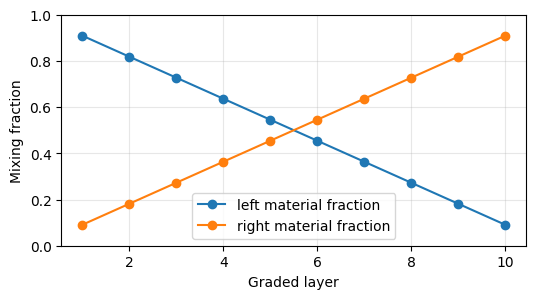

In [4]:
material_2_fraction = utils_graded_layers.get_mixing_ratios(num_graded_layers)

fig, ax = plt.subplots(figsize=(6, 3))
layer_numbers = jnp.arange(1, num_graded_layers + 1)
ax.plot(layer_numbers, 1 - material_2_fraction, "o-", label="left material fraction")
ax.plot(layer_numbers, material_2_fraction, "o-", label="right material fraction")
ax.set_xlabel("Graded layer")
ax.set_ylabel("Mixing fraction")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)


A stack drawing makes the effect of `interface_indices` visible. The abrupt stack has three positive-thickness layers, while the graded stack inserts mixed sublayers only at the selected internal interfaces. Zero-thickness air layers are shown as boundary markers.


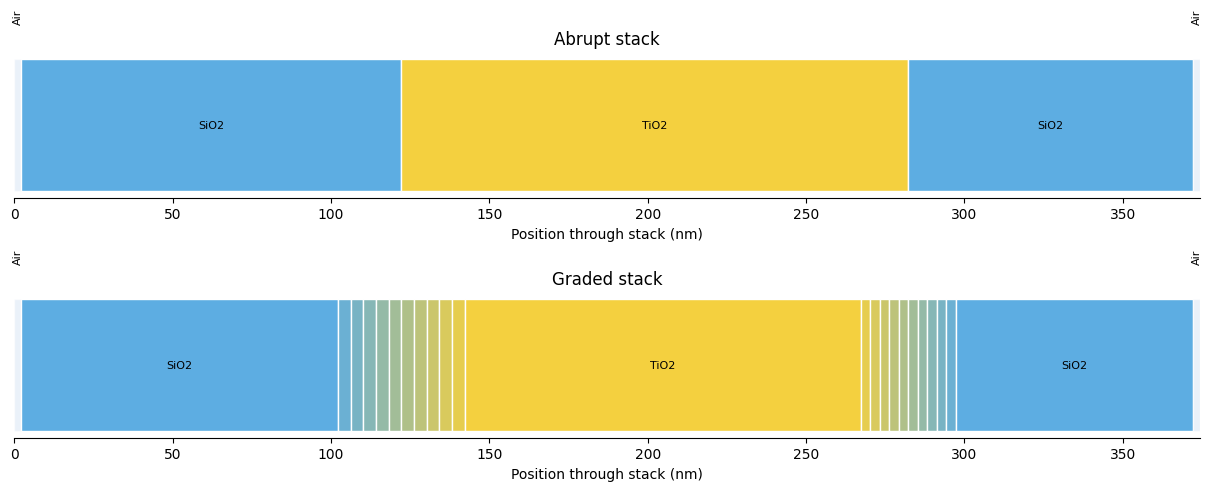

In [5]:
material_colors = {
    "Air": "#d9e7f5",
    "SiO2": "#5DADE2",
    "TiO2": "#F4D03F",
    "graded": "#95A5A6",
}


def blend_colors(left_color, right_color, ratio):
    left_rgb = jnp.array(to_rgb(left_color))
    right_rgb = jnp.array(to_rgb(right_color))
    blended = (1 - ratio) * left_rgb + ratio * right_rgb
    return tuple(float(value) for value in blended)


def build_graded_layer_labels_and_colors(layer_labels, interface_indices, num_graded_layers):
    selected_interfaces = {int(interface_index) for interface_index in interface_indices}
    ratios = utils_graded_layers.get_mixing_ratios(num_graded_layers)
    plotted_labels = []
    plotted_colors = []

    for layer_index, label in enumerate(layer_labels):
        plotted_labels.append(label)
        plotted_colors.append(material_colors[label])

        if layer_index in selected_interfaces:
            left_color = material_colors[layer_labels[layer_index]]
            right_color = material_colors[layer_labels[layer_index + 1]]
            for ratio in ratios:
                plotted_labels.append("graded")
                plotted_colors.append(blend_colors(left_color, right_color, float(ratio)))

    return plotted_labels, plotted_colors


def plot_layer_stack(ax, thicknesses, labels, colors, title):
    thicknesses_nm = [float(value) for value in utils_units.convert_m_to_nm(thicknesses)]
    positive_thicknesses = [width for width in thicknesses_nm if width > 0]
    marker_width = max(sum(positive_thicknesses), 1.0) * 0.006
    x_position = 0.0

    for width, label, color in zip(thicknesses_nm, labels, colors):
        draw_width = width if width > 0 else marker_width
        alpha = 1.0 if width > 0 else 0.55
        ax.barh(0, draw_width, left=x_position, height=0.55, color=color, edgecolor="white", alpha=alpha)

        if width > 6:
            ax.text(x_position + draw_width / 2, 0, label, ha="center", va="center", fontsize=8)
        elif width == 0:
            ax.text(x_position + draw_width / 2, 0.42, label, ha="center", va="bottom", fontsize=8, rotation=90)

        x_position += draw_width

    ax.set_title(title)
    ax.set_xlabel("Position through stack (nm)")
    ax.set_yticks([])
    ax.set_xlim(0, x_position)
    ax.spines[["left", "right", "top"]].set_visible(False)


abrupt_labels = materials
abrupt_colors = [material_colors[label] for label in abrupt_labels]
graded_labels, graded_colors = build_graded_layer_labels_and_colors(
    materials,
    interface_indices,
    num_graded_layers,
)

fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), constrained_layout=True)
plot_layer_stack(axes[0], thicknesses_abrupt, abrupt_labels, abrupt_colors, "Abrupt stack")
plot_layer_stack(axes[1], thicknesses_graded, graded_labels, graded_colors, "Graded stack")


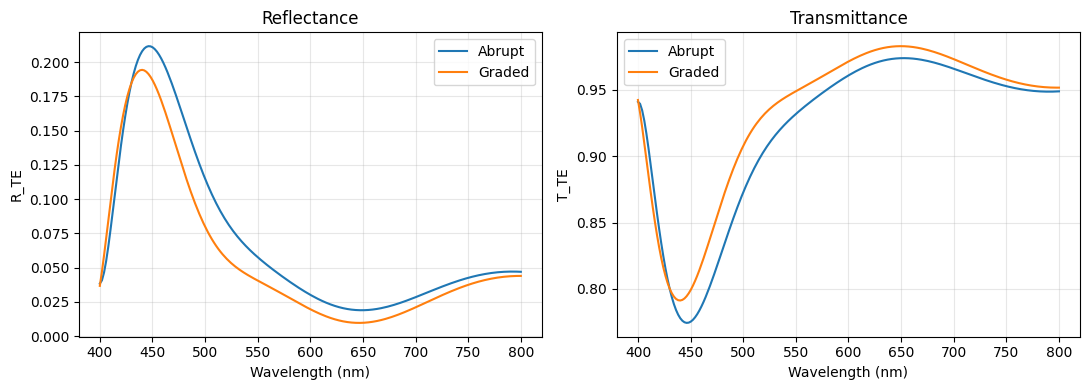

In [6]:
R_TE_abrupt, T_TE_abrupt, _, _ = stackrt(n_k_abrupt, thicknesses_abrupt, frequencies, 0.0)
R_TE_graded, T_TE_graded, _, _ = stackrt(n_k_graded, thicknesses_graded, frequencies, 0.0)

wavelengths_nm = utils_units.convert_m_to_nm(wavelengths)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
axes[0].plot(wavelengths_nm, R_TE_abrupt[0], label="Abrupt")
axes[0].plot(wavelengths_nm, R_TE_graded[0], label="Graded")
axes[0].set_title("Reflectance")
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("R_TE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(wavelengths_nm, T_TE_abrupt[0], label="Abrupt")
axes[1].plot(wavelengths_nm, T_TE_graded[0], label="Graded")
axes[1].set_title("Transmittance")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("T_TE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
